# CorrQEC Tutorial
## Detrimental Non-Markovian Errors for Surface Code Memory

**Paper:** [Quantum Science and Technology, 2025](https://iopscience.iop.org/article/10.1088/2058-9565/adebab)  
**arXiv:** [2410.23779](https://arxiv.org/abs/2410.23779)  
**Authors:** F Kam, John; Gicev, Spiro; Modi, Kavan; Southwell, Angus; Usman, Muhammad

---

### What this paper is about

Fault-tolerant quantum computing relies on quantum error correction (QEC). Most QEC analyses assume **Markovian** (memoryless) noise — errors at each moment are independent of the past. Real devices, however, exhibit **non-Markovian** (temporally correlated) errors.

This paper asks: *does temporal correlation in errors hurt surface code performance, and by how much?*

The key finding is that **not all** correlated structures are equally detrimental:
- Correlated errors on **data qubits** (Class 0): comparable to independent noise
- Correlated errors on **syndrome measurement qubits** (Class 1): slightly worse
- Correlated "streaky" errors on **syndrome qubits or two-qubit gates** (Class 1/2, streaky): **severely** degrade logical error rate scaling

### Noise model taxonomy

| Class | Error location | Corr. structure | Model class |
|-------|---------------|-----------------|-------------|
| 0 | Data qubits | Pairwise / Streaky | `LongTimePairPoly`, `LongTimeStreakPoly` |
| 1 | Syndrome (measure) qubits | Pairwise / Streaky | `LongTimePairMPoly`, `LongTimeStreakMPoly` |
| 2 | Two-qubit gate (CX) | Pairwise / Streaky | `LongTimePairCPoly`, `LongTimeStreakCPoly` |
| All | All qubits combined | Pairwise / Streaky | `LongTimePairAPoly`, `LongTimeStreakAPoly` |

**Pairwise** — a pair of rounds $(t_a, t_b)$ are correlated; if an error fires, it affects both rounds.  
**Streaky** — all rounds in a streak $[t_a, t_b]$ are correlated; one event triggers errors across a span of consecutive rounds.

**Decay functions** control how correlation strength falls off with round separation $r = t_b - t_a$:
- **Polynomial:** $p_{ab} = A \cdot p / r^n$
- **Exponential:** $p_{ab} = A \cdot p / n^r$

Crucially, the **marginal** (per-round average) error rate is kept constant across correlated and independent models, so any difference in logical error rate is purely due to correlations.

---
## 1. Setup

Make sure you are running this notebook from the **project root** (`corrqec/`). Install dependencies if needed:

```bash
python -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```

In [9]:
import sys
import os

# Ensure the project root is on the Python path
project_root = os.path.abspath('.')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Create output directories if they don't already exist
for path in [
    'data/output/experiment1/class0',
    'data/output/experiment1/class1',
    'data/output/experiment1/class2',
    'data/output/experiment2/class1',
    'data/output/experiment2/class2',
    'data/output/experiment3',
    'data/output/experiment4',
    'figures/output',
]:
    os.makedirs(path, exist_ok=True)

print("Setup complete.")

Setup complete.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import stim
import sinter

# Noise models
from src.noisemodel import (
    LongTimePairPoly,   LongTimeStreakPoly,
    LongTimePairMPoly,  LongTimeStreakMPoly,
    LongTimePairCPoly,  LongTimeStreakCPoly,
    LongTimePairAPoly,  LongTimeStreakAPoly,
    LongTimePairExp,    LongTimeStreakExp,
    LongTimeStreakMExp,
    poly_decay, exp_decay,
)

# Sampling
from src.sample import sample_correlated_to_file, sample_independent_to_file
from src.sample.sample import sample_correlated

# Analysis — calc_per_round_ci is in the submodule but not re-exported from __init__
from src.analysis import convert_stats_for_projection, collate_stats_for_projection
from src.analysis.stats import calc_per_round_ci

# Utilities
from src.util import stats_from_csv, gen_csv_filepaths, gen_csv_filepath_list

# Visualization
from src.visualization.plot import plot_threshold, plot_projection_multi

print("Imports successful.")

Imports successful.


---
## 2. Surface Code Circuits with Stim

The experiments use `stim.Circuit.generated` to create rotated-memory-Z surface code circuits. The key parameters are:
- `distance` — code distance $d$ (odd integer; logical error rate scales as $\sim p^{\lceil d/2 \rceil}$ for independent noise)
- `rounds` — number of syndrome measurement rounds (paper uses $r = 2d$)
- Optional sub-circuit-level (SCL) noise channels (e.g. `after_clifford_depolarization`)

Let's inspect a small surface code circuit:

In [13]:
d, r = 3, 6
circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=r,
    distance=d,
)

print(f"Surface code distance-{d}, {r} rounds")
print(f"Number of instructions: {len(circuit)}")
print()
# Print first 30 lines of the circuit
circuit_str = str(circuit)
for line in circuit_str.split('\n')[:30]:
    print(line)

Surface code distance-3, 6 rounds
Number of instructions: 43

QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
TICK
H 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25


---
## 3. Noise Model Basics

All noise models take two main parameters:
- `p` — the base physical error probability (sets the marginal error rate)
- `A` — amplitude prefactor for the interaction function
- `n` — decay exponent (polynomial) or base (exponential)

The interaction function between rounds $t_a$ and $t_b$ (separation $r = t_b - t_a$) is:

$$p_{ab}^{\text{poly}} = \frac{A \cdot p}{r^n}, \qquad p_{ab}^{\text{exp}} = \frac{A \cdot p}{n^r}$$

As $r \to \infty$, $p_{ab} \to 0$, recovering independent noise. Setting $n = \infty$ (polynomial) gives exactly independent noise.

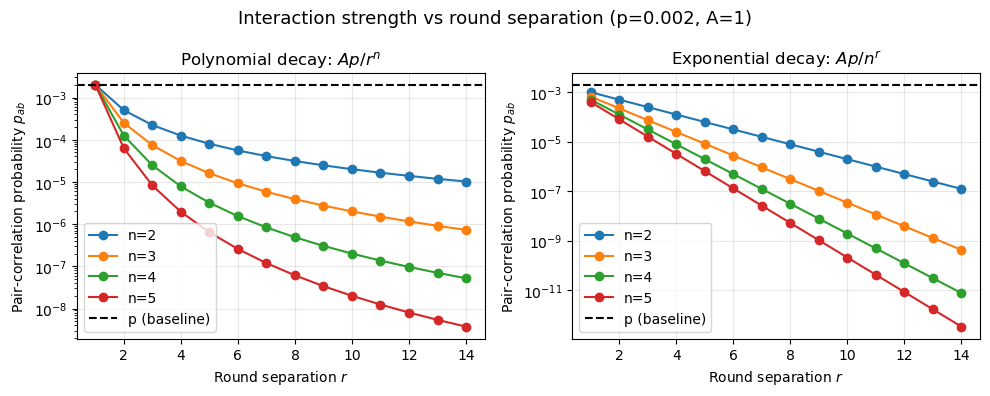

In [14]:
# Visualise how pair-correlation probability decays with round separation
r_vals = np.arange(1, 15)
p = 2e-3
A = 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for n in [2, 3, 4, 5]:
    axes[0].plot(r_vals, poly_decay(r_vals, A, p, n), marker='o', label=f'n={n}')
    axes[1].plot(r_vals, exp_decay(r_vals, A, p, n), marker='o', label=f'n={n}')

axes[0].axhline(p, color='k', linestyle='--', label='p (baseline)')
axes[1].axhline(p, color='k', linestyle='--', label='p (baseline)')

for ax, title in zip(axes, ['Polynomial decay: $A p / r^n$', 'Exponential decay: $A p / n^r$']):
    ax.set_xlabel('Round separation $r$')
    ax.set_ylabel('Pair-correlation probability $p_{ab}$')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

fig.suptitle(f'Interaction strength vs round separation (p={p}, A={A})', fontsize=13)
fig.tight_layout()
plt.show()

### 3.1 Instantiating a noise model and sampling

The `sample_logical_error_rate` method on any noise model returns the estimated logical error rate for a given circuit.

In [15]:
# Quick single-model test with small parameters
d, r, p = 3, 6, 2e-3
A, n = 1, 2

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=r,
    distance=d,
)

model = LongTimePairPoly(p=p, A=A, n=n, noisy_qubits='data')

# Small run for demonstration (paper uses batch_size=1000, repetitions=10000)
shots, errors = model.sample_logical_error_rate(
    circuit,
    repetitions=10,
    batch_size=500,
    return_error_rate=False,
)

per_round, ci_low, ci_high = calc_per_round_ci(errors, shots, r)
print(f"Model : LongTimePairPoly(A={A}, n={n}, p={p})")
print(f"d={d}, r={r}")
print(f"Shots  : {shots}")
print(f"Errors : {errors}")
print(f"Logical error rate per round: {per_round:.4e}  [{per_round - ci_low:.4e}, {per_round + ci_high:.4e}] (95% CI)")

Model : LongTimePairPoly(A=1, n=2, p=0.002)
d=3, r=6
Shots  : 5000
Errors : 28
Logical error rate per round: 9.3772e-04  [5.9034e-04, 1.2863e-03] (95% CI)


---
## 4. Experiment 1 — Class Comparison (paper §3)

This experiment compares correlated vs. independent noise for three classes of error location, using polynomial decay with $n=2$.

**Exact paper parameters:**

| Class | Error location | Model | A | n | Distances | p | max_shots |
|-------|---------------|-------|---|---|-----------|---|----------|
| 0 | Data qubits | `LongTimePairPoly`, `LongTimeStreakPoly` | 1 | 2 | 3–15 | 2e-3 | 10M |
| 1 | Syndrome qubits | `LongTimePairMPoly`, `LongTimeStreakMPoly` | 1 | 2 | 3–13 | 2e-3 | 10K |
| 2 | Two-qubit gates | `LongTimePairCPoly`, `LongTimeStreakCPoly` | 0.5 | 2 | 3–15 | 2e-3 | 10M |

Each class also includes **sub-circuit-level (SCL) noise** to model background Markovian errors:
- Class 0: `after_clifford_depolarization`, `before_measure_flip_probability`, `after_reset_flip_probability`
- Class 1: `before_round_data_depolarization`, `after_clifford_depolarization`, `after_reset_flip_probability`
- Class 2: `before_round_data_depolarization`, `before_measure_flip_probability`, `after_reset_flip_probability`

For each model, both correlated and marginalized-independent versions are simulated so results can be compared at identical marginal error rates.

### 4.1 Class 0 — Data Qubit Errors

Errors are injected onto **data qubits** only. The SCL noise represents gate, measurement and reset errors.

In [16]:
# ─── PAPER PARAMETERS ─────────────────────────────────────────────────────────
kwargs_class0 = {
    "num_workers": 12,
    "model_params": {"A": 1, "n": 2, "noisy_qubits": "data"},
    "distances": [3, 5, 7, 9, 11, 13, 15],
    "probabilities": [2e-3],
    "scl_noise": [
        "after_clifford_depolarization",
        "before_measure_flip_probability",
        "after_reset_flip_probability",
    ],
    "max_shots": 10_000_000,
    "print_progress": True,
}
# ──────────────────────────────────────────────────────────────────────────────

# QUICK DEMO PARAMETERS (reduced for fast execution)
kwargs_class0_demo = {
    **kwargs_class0,
    "distances": [3, 5, 7],
    "max_shots": 5_000,
    "num_workers": 4,
    "print_progress": False,
}

print("Class 0 paper parameters:")
for k, v in kwargs_class0.items():
    print(f"  {k}: {v}")

Class 0 paper parameters:
  num_workers: 12
  model_params: {'A': 1, 'n': 2, 'noisy_qubits': 'data'}
  distances: [3, 5, 7, 9, 11, 13, 15]
  probabilities: [0.002]
  scl_noise: ['after_clifford_depolarization', 'before_measure_flip_probability', 'after_reset_flip_probability']
  max_shots: 10000000
  print_progress: True


In [18]:
# Run Class 0 — DEMO (small scale)
# To reproduce the paper, replace kwargs_class0_demo with kwargs_class0

fp_class0_pair_corr, fp_class0_pair_indep = gen_csv_filepaths(
    './data/output/experiment1/class0/', 'pair_data_poly', counter=None
)
fp_class0_streak_corr, fp_class0_streak_indep = gen_csv_filepaths(
    './data/output/experiment1/class0/', 'streak_data_poly', counter=None
)

print("Running Class 0 — Pairwise correlated (demo scale)...")
sample_correlated_to_file(
    filepath=fp_class0_pair_corr,
    NoiseModel=LongTimePairPoly,
    **kwargs_class0_demo,
)

print("Running Class 0 — Pairwise independent (demo scale)...")
sample_independent_to_file(
    filepath=fp_class0_pair_indep,
    NoiseModel=LongTimePairPoly,
    **kwargs_class0_demo,
)

print("Running Class 0 — Streak correlated (demo scale)...")
sample_correlated_to_file(
    filepath=fp_class0_streak_corr,
    NoiseModel=LongTimeStreakPoly,
    **kwargs_class0_demo,
)

print("Running Class 0 — Streak independent (demo scale)...")
sample_independent_to_file(
    filepath=fp_class0_streak_indep,
    NoiseModel=LongTimeStreakPoly,
    **kwargs_class0_demo,
)

print("Done.")

Running Class 0 — Pairwise correlated (demo scale)...
({3: [0.002], 5: [0.002], 7: [0.002]}, {3: [[5000, 49, 6]], 5: [[5000, 14, 10]], 7: [[5000, 4, 14]]})
Running Class 0 — Pairwise independent (demo scale)...
Running Class 0 — Streak correlated (demo scale)...
({3: [0.002], 5: [0.002], 7: [0.002]}, {3: [[5000, 49, 6]], 5: [[5000, 19, 10]], 7: [[5000, 8, 14]]})
Running Class 0 — Streak independent (demo scale)...
Done.


### 4.2 Class 1 — Syndrome Measurement Qubit Errors

Errors are injected onto **syndrome (ancilla) qubits** only, i.e. qubits measured at the end of each round. Note the smaller default `max_shots=10_000` in the paper — this class is more expensive per shot.

In [19]:
# ─── PAPER PARAMETERS ─────────────────────────────────────────────────────────
kwargs_class1 = {
    "num_workers": 12,
    "model_params": {"A": 1, "n": 2},
    "distances": [3, 5, 7, 9, 11, 13],
    "probabilities": [2e-3],
    "scl_noise": [
        "before_round_data_depolarization",
        "after_clifford_depolarization",
        "after_reset_flip_probability",
    ],
    "max_shots": 10_000,
    "print_progress": True,
}
# ──────────────────────────────────────────────────────────────────────────────

kwargs_class1_demo = {
    **kwargs_class1,
    "distances": [3, 5],
    "max_shots": 2_000,
    "num_workers": 2,
    "print_progress": False,
}

print("Class 1 paper parameters:")
for k, v in kwargs_class1.items():
    print(f"  {k}: {v}")

Class 1 paper parameters:
  num_workers: 12
  model_params: {'A': 1, 'n': 2}
  distances: [3, 5, 7, 9, 11, 13]
  probabilities: [0.002]
  scl_noise: ['before_round_data_depolarization', 'after_clifford_depolarization', 'after_reset_flip_probability']
  max_shots: 10000
  print_progress: True


In [20]:
# Run Class 1 — DEMO (small scale)

fp_class1_pair_corr, fp_class1_pair_indep = gen_csv_filepaths(
    './data/output/experiment1/class1/', 'pair_m_poly', counter=None
)
fp_class1_streak_corr, fp_class1_streak_indep = gen_csv_filepaths(
    './data/output/experiment1/class1/', 'streak_m_poly', counter=None
)

print("Running Class 1 — Pairwise correlated...")
sample_correlated_to_file(
    filepath=fp_class1_pair_corr, NoiseModel=LongTimePairMPoly, **kwargs_class1_demo
)

print("Running Class 1 — Pairwise independent...")
sample_independent_to_file(
    filepath=fp_class1_pair_indep, NoiseModel=LongTimePairMPoly, **kwargs_class1_demo
)

print("Running Class 1 — Streak correlated...")
sample_correlated_to_file(
    filepath=fp_class1_streak_corr, NoiseModel=LongTimeStreakMPoly, **kwargs_class1_demo
)

print("Running Class 1 — Streak independent...")
sample_independent_to_file(
    filepath=fp_class1_streak_indep, NoiseModel=LongTimeStreakMPoly, **kwargs_class1_demo
)

print("Done.")

Running Class 1 — Pairwise correlated...
({3: [0.002], 5: [0.002]}, {3: [[2000, 14, 6]], 5: [[2000, 9, 10]]})
Running Class 1 — Pairwise independent...
Running Class 1 — Streak correlated...
({3: [0.002], 5: [0.002]}, {3: [[2000, 18, 6]], 5: [[2000, 10, 10]]})
Running Class 1 — Streak independent...
Done.


### 4.3 Class 2 — Two-Qubit Gate (CX) Errors

Errors are injected on the **control qubits** of CX (CNOT) gates, which connect data and syndrome qubits. The amplitude is set to `A=0.5` (rather than 1.0) to account for the two-qubit scaling.

In [21]:
# ─── PAPER PARAMETERS ─────────────────────────────────────────────────────────
kwargs_class2 = {
    "num_workers": 12,
    "model_params": {"A": 0.5, "n": 2},
    "distances": [3, 5, 7, 9, 11, 13, 15],
    "probabilities": [2e-3],
    "scl_noise": [
        "before_round_data_depolarization",
        "before_measure_flip_probability",
        "after_reset_flip_probability",
    ],
    "max_shots": 10_000_000,
    "print_progress": True,
}
# ──────────────────────────────────────────────────────────────────────────────

kwargs_class2_demo = {
    **kwargs_class2,
    "distances": [3, 5, 7],
    "max_shots": 5_000,
    "num_workers": 4,
    "print_progress": False,
}

print("Class 2 paper parameters:")
for k, v in kwargs_class2.items():
    print(f"  {k}: {v}")

Class 2 paper parameters:
  num_workers: 12
  model_params: {'A': 0.5, 'n': 2}
  distances: [3, 5, 7, 9, 11, 13, 15]
  probabilities: [0.002]
  scl_noise: ['before_round_data_depolarization', 'before_measure_flip_probability', 'after_reset_flip_probability']
  max_shots: 10000000
  print_progress: True


In [22]:
# Run Class 2 — DEMO (small scale)

fp_class2_pair_corr, fp_class2_pair_indep = gen_csv_filepaths(
    './data/output/experiment1/class2/', 'pair_c_poly', counter=None
)
fp_class2_streak_corr, fp_class2_streak_indep = gen_csv_filepaths(
    './data/output/experiment1/class2/', 'streak_c_poly', counter=None
)

print("Running Class 2 — Pairwise correlated...")
sample_correlated_to_file(
    filepath=fp_class2_pair_corr, NoiseModel=LongTimePairCPoly, **kwargs_class2_demo
)

print("Running Class 2 — Pairwise independent...")
sample_independent_to_file(
    filepath=fp_class2_pair_indep, NoiseModel=LongTimePairCPoly, **kwargs_class2_demo
)

print("Running Class 2 — Streak correlated...")
sample_correlated_to_file(
    filepath=fp_class2_streak_corr, NoiseModel=LongTimeStreakCPoly, **kwargs_class2_demo
)

print("Running Class 2 — Streak independent...")
sample_independent_to_file(
    filepath=fp_class2_streak_indep, NoiseModel=LongTimeStreakCPoly, **kwargs_class2_demo
)

print("Done.")

Running Class 2 — Pairwise correlated...
({3: [0.002], 5: [0.002], 7: [0.002]}, {3: [[5000, 52, 6]], 5: [[5000, 15, 10]], 7: [[5000, 6, 14]]})
Running Class 2 — Pairwise independent...
Running Class 2 — Streak correlated...
({3: [0.002], 5: [0.002], 7: [0.002]}, {3: [[5000, 67, 6]], 5: [[5000, 29, 10]], 7: [[5000, 13, 14]]})
Running Class 2 — Streak independent...
Done.


### 4.4 Running the full paper-scale Experiment 1

The cells above run with reduced parameters for speed. To reproduce the paper exactly, use the scripts from the project root:

```bash
python -m scripts.experiment1.class0   # ~hours, 12 workers, 10M shots
python -m scripts.experiment1.class1   # ~minutes, 10K shots
python -m scripts.experiment1.class2   # ~hours, 10M shots
```

Or pass `kwargs_class0` (instead of `kwargs_class0_demo`) directly in the cells above.

---
## 5. Plotting Experiment 1 — Using Saved Data

The repository ships with pre-computed results in `data/saved/`. We use those here to reproduce the paper figures immediately.

In [23]:
# Helper functions to load saved data
def load_correlated(filepath):
    stats = stats_from_csv(filepath)
    return convert_stats_for_projection(stats)

def load_independent(filepath):
    stats = sinter.read_stats_from_csv_files(filepath)
    return collate_stats_for_projection(stats)

def format_for_plot(data):
    x = next(iter(data[0].values()))
    per_rounds = np.array(next(iter(data[1].values())))
    y = per_rounds[:, 0]
    yerr = per_rounds[:, 1:].T
    return x, y, yerr

In [24]:
# Load saved Experiment 1 data
saved_base = 'data/saved/experiment1'

corr_files = [
    f'{saved_base}/class0/pair_data_poly_correlated.csv',
    f'{saved_base}/class0/streak_data_poly_correlated.csv',
    f'{saved_base}/class1/pair_m_poly_correlated.csv',
    f'{saved_base}/class1/streak_m_poly_correlated.csv',
    f'{saved_base}/class2/pair_c_poly_correlated.csv',
    f'{saved_base}/class2/streak_c_poly_correlated.csv',
]
indep_files = [
    f'{saved_base}/class0/pair_data_poly_independent.csv',
    f'{saved_base}/class0/streak_data_poly_independent.csv',
    f'{saved_base}/class1/pair_m_poly_independent.csv',
    f'{saved_base}/class1/streak_m_poly_independent.csv',
    f'{saved_base}/class2/pair_c_poly_independent.csv',
    f'{saved_base}/class2/streak_c_poly_independent.csv',
]

titles = [
    'Class 0 — Pairwise (data qubits)',
    'Class 0 — Streaky (data qubits)',
    'Class 1 — Pairwise (syndrome qubits)',
    'Class 1 — Streaky (syndrome qubits)',
    'Class 2 — Pairwise (two-qubit gates)',
    'Class 2 — Streaky (two-qubit gates)',
]

data_corr = [load_correlated(fp) for fp in corr_files]
data_indep = [load_independent(fp) for fp in indep_files]

print("Saved data loaded.")

Saved data loaded.


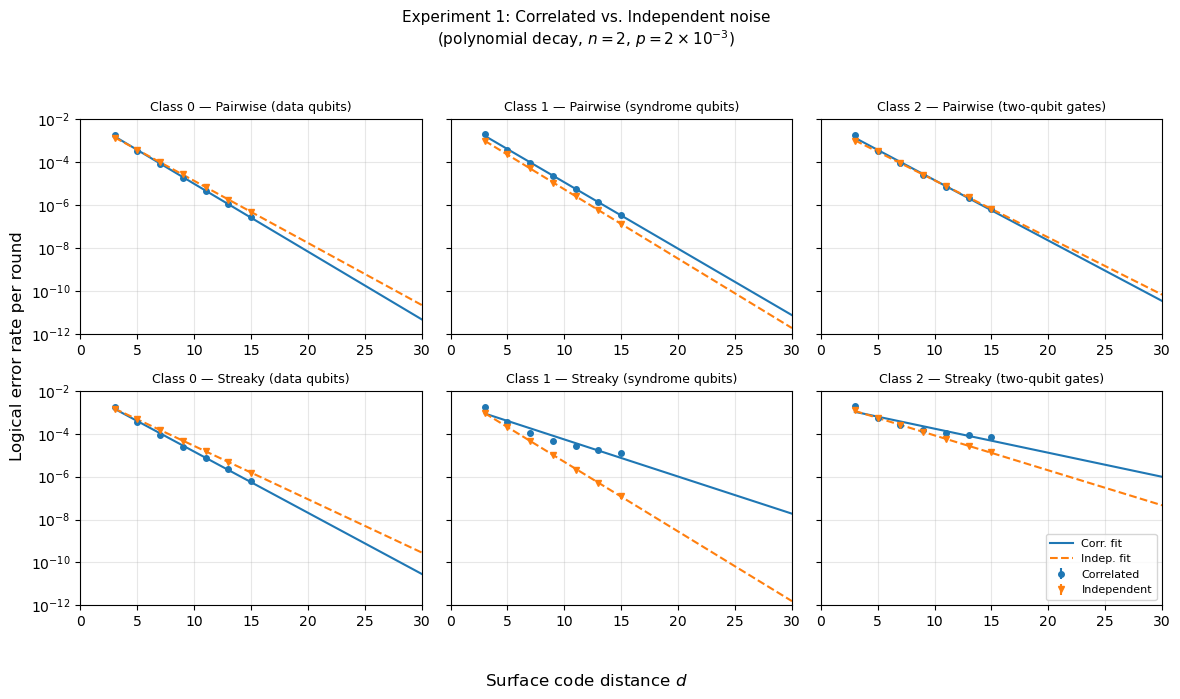

In [25]:
# Reproduce Figure from paper: logical error rate per round vs. distance
# Correlated noise vs. independent noise (same marginal error rate)

coords = [(0, 0), (1, 0), (0, 1), (1, 1), (0, 2), (1, 2)]
e = np.e

fig, axs = plt.subplots(2, 3, figsize=(12, 7))

prop_cycle = plt.rcParams['axes.prop_cycle']
color1, color2 = prop_cycle.by_key()['color'][:2]

for i in range(6):
    ax = axs[coords[i]]
    x_corr, y_corr, yerr_corr = format_for_plot(data_corr[i])
    x_indep, y_indep, yerr_indep = format_for_plot(data_indep[i])

    ax.errorbar(x_corr, y_corr, yerr=yerr_corr,
                label='Correlated', fmt='o', markersize=4, color=color1)
    ax.errorbar(x_indep, y_indep, yerr=yerr_indep,
                label='Independent', fmt='v', markersize=4, color=color2)

    # Linear fit in log-y space
    coeffs_corr = np.polyfit(x_corr, np.log(y_corr), 1)
    coeffs_indep = np.polyfit(x_indep, np.log(y_indep), 1)
    x_fit = np.linspace(3, 30, 100)
    ax.plot(x_fit, e ** np.polyval(coeffs_corr, x_fit), color=color1, label='Corr. fit')
    ax.plot(x_fit, e ** np.polyval(coeffs_indep, x_fit), color=color2, linestyle='--', label='Indep. fit')

    ax.semilogy()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 30])
    ax.set_ylim([1e-12, 1e-2])
    ax.set_title(titles[i], fontsize=9)
    if i not in [0, 1]:
        ax.set_yticklabels([])

plt.subplots_adjust(wspace=0, hspace=0.35)
axs[coords[5]].legend(loc='lower right', fontsize=8)
fig.supxlabel('Surface code distance $d$', fontsize=12)
fig.supylabel('Logical error rate per round', fontsize=12)
fig.suptitle('Experiment 1: Correlated vs. Independent noise\n(polynomial decay, $n=2$, $p=2\\times10^{-3}$)', fontsize=11)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Reading the figure:** Each panel shows logical error rate per round (y-axis, log scale) vs. code distance (x-axis). For good QEC, the rate should drop exponentially with distance.

- **Class 0 (data qubits):** Correlated and independent noise behave similarly — correlations on data qubits are not detrimental.
- **Class 1 Streaky & Class 2 Streaky:** The correlated model (orange circles) decays *much* more slowly with distance than the independent model (blue triangles). This is the key finding.

---
## 6. Experiment 2 — Decay Exponent Sweep (paper §4)

This sweeps the decay parameter `n` in $\{2, 3, 4, 5, \infty\}$ to show how the severity depends on the temporal correlation length.

- $n = 2$: slowest decay (strongest long-range correlations)
- $n = \infty$: recovers independent noise (no correlations beyond adjacent rounds)

**Paper parameters:**
- Models: `LongTimeStreakMPoly` (Class 1 syndrome, polynomial)
- Distances: [3, 5, 7, 9, 11, 13, 15]
- `p = 2e-3`, `A = 1`
- SCL noise: `before_round_data_depolarization`, `after_clifford_depolarization`, `after_reset_flip_probability`
- `max_shots = 10_000_000`

In [26]:
# ─── PAPER PARAMETERS ─────────────────────────────────────────────────────────
kwargs_exp2_base = {
    "num_workers": 12,
    "distances": [3, 5, 7, 9, 11, 13, 15],
    "probabilities": [2e-3],
    "scl_noise": [
        "before_round_data_depolarization",
        "after_clifford_depolarization",
        "after_reset_flip_probability",
    ],
    "max_shots": 10_000_000,
    "print_progress": False,
}

# Five parameter sets varying n
exp2_params_list = [
    {"A": 1, "n": 2},
    {"A": 1, "n": 3},
    {"A": 1, "n": 4},
    {"A": 1, "n": 5},
    {"A": 1, "n": float('inf')},
]

exp2_names = [
    'streak_m_poly_a1n2',
    'streak_m_poly_a1n3',
    'streak_m_poly_a1n4',
    'streak_m_poly_a1n5',
    'streak_m_poly_a1ninf',
]

exp2_labels = ['n=2', 'n=3', 'n=4', 'n=5', 'n=∞ (independent)']
# ──────────────────────────────────────────────────────────────────────────────

# Demo: only 2 parameter sets, 3 distances, 3000 shots
kwargs_exp2_demo = {
    **kwargs_exp2_base,
    "distances": [3, 5, 7],
    "max_shots": 3_000,
    "num_workers": 4,
}

print("Experiment 2 decay parameter sweep:")
for params, name in zip(exp2_params_list, exp2_names):
    print(f"  {name}: {params}")

Experiment 2 decay parameter sweep:
  streak_m_poly_a1n2: {'A': 1, 'n': 2}
  streak_m_poly_a1n3: {'A': 1, 'n': 3}
  streak_m_poly_a1n4: {'A': 1, 'n': 4}
  streak_m_poly_a1n5: {'A': 1, 'n': 5}
  streak_m_poly_a1ninf: {'A': 1, 'n': inf}


In [27]:
# Run Experiment 2 — DEMO (2 out of 5 parameter sets)

exp2_filepaths = gen_csv_filepath_list('./data/output/experiment2/class1/', exp2_names)

for i in range(2):   # Demo: only n=2 and n=5 for speed
    print(f"Running {exp2_names[i]} ({exp2_labels[i]})...")
    sample_correlated_to_file(
        filepath=exp2_filepaths[i],
        NoiseModel=LongTimeStreakMPoly,
        model_params=exp2_params_list[i],
        **kwargs_exp2_demo,
    )

print("Done (demo subset).")
print()
print("To run all 5 parameter sets at paper scale:")
print("  python -m scripts.experiment2.class1_poly")

Running streak_m_poly_a1n2 (n=2)...
({3: [0.002], 5: [0.002], 7: [0.002]}, {3: [[3000, 30, 6]], 5: [[3000, 13, 10]], 7: [[3000, 7, 14]]})
Running streak_m_poly_a1n3 (n=3)...
({3: [0.002], 5: [0.002], 7: [0.002]}, {3: [[3000, 31, 6]], 5: [[3000, 8, 10]], 7: [[3000, 3, 14]]})
Done (demo subset).

To run all 5 parameter sets at paper scale:
  python -m scripts.experiment2.class1_poly


### 6.1 Experiment 2 — Loading and Plotting Saved Data

In [28]:
# Check which experiment 2 saved files are available
import glob
exp2_saved = sorted(glob.glob('data/saved/experiment2/**/*.csv', recursive=True))
print(f"Found {len(exp2_saved)} saved experiment 2 files:")
for f in exp2_saved:
    print(' ', f)

Found 20 saved experiment 2 files:
  data/saved/experiment2/class1/streak_m_exp_a1n2.csv
  data/saved/experiment2/class1/streak_m_exp_a1n3.csv
  data/saved/experiment2/class1/streak_m_exp_a1n4.csv
  data/saved/experiment2/class1/streak_m_exp_a1n5.csv
  data/saved/experiment2/class1/streak_m_exp_a1ninf.csv
  data/saved/experiment2/class1/streak_m_poly_a1n2.csv
  data/saved/experiment2/class1/streak_m_poly_a1n3.csv
  data/saved/experiment2/class1/streak_m_poly_a1n4.csv
  data/saved/experiment2/class1/streak_m_poly_a1n5.csv
  data/saved/experiment2/class1/streak_m_poly_a1ninf.csv
  data/saved/experiment2/class2/streak_c_exp_a1n2.csv
  data/saved/experiment2/class2/streak_c_exp_a1n3.csv
  data/saved/experiment2/class2/streak_c_exp_a1n4.csv
  data/saved/experiment2/class2/streak_c_exp_a1n5.csv
  data/saved/experiment2/class2/streak_c_exp_a1ninf.csv
  data/saved/experiment2/class2/streak_c_poly_a1n2.csv
  data/saved/experiment2/class2/streak_c_poly_a1n3.csv
  data/saved/experiment2/class2/st

In [29]:
# Load all saved experiment 2 correlated data (class1 polynomial sweep)
exp2_saved_base = 'data/saved/experiment2'
exp2_corr_files = [
    f'{exp2_saved_base}/class1/streak_m_poly_a1n2_correlated.csv',
    f'{exp2_saved_base}/class1/streak_m_poly_a1n3_correlated.csv',
    f'{exp2_saved_base}/class1/streak_m_poly_a1n4_correlated.csv',
    f'{exp2_saved_base}/class1/streak_m_poly_a1n5_correlated.csv',
    f'{exp2_saved_base}/class1/streak_m_poly_a1ninf_correlated.csv',
]

exp2_data = []
for fp in exp2_corr_files:
    if os.path.exists(fp):
        exp2_data.append(load_correlated(fp))
        print(f"Loaded: {fp}")
    else:
        print(f"Missing: {fp}")

Missing: data/saved/experiment2/class1/streak_m_poly_a1n2_correlated.csv
Missing: data/saved/experiment2/class1/streak_m_poly_a1n3_correlated.csv
Missing: data/saved/experiment2/class1/streak_m_poly_a1n4_correlated.csv
Missing: data/saved/experiment2/class1/streak_m_poly_a1n5_correlated.csv
Missing: data/saved/experiment2/class1/streak_m_poly_a1ninf_correlated.csv


In [30]:
# Plot Experiment 2: effect of decay exponent n on logical error rate
if exp2_data:
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(exp2_data)))
    markers = ['o', 's', '^', 'D', 'v']

    for i, (data, label, color, marker) in enumerate(zip(
        exp2_data, exp2_labels[:len(exp2_data)], colors, markers
    )):
        x, y, yerr = format_for_plot(data)
        ax.errorbar(x, y, yerr=yerr, label=label, fmt=marker,
                    markersize=5, color=color, capsize=2)
        coeffs = np.polyfit(x, np.log(y), 1)
        x_fit = np.linspace(3, 20, 100)
        ax.plot(x_fit, e ** np.polyval(coeffs, x_fit), color=color, linestyle='--', alpha=0.6)

    ax.semilogy()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 20])
    ax.set_xlabel('Surface code distance $d$')
    ax.set_ylabel('Logical error rate per round')
    ax.set_title('Experiment 2: Effect of decay exponent $n$\n(Streaky syndrome errors, polynomial decay, $p=2\\times10^{-3}$)')
    ax.legend(title='Decay exponent')
    fig.tight_layout()
    plt.show()
else:
    print("No saved experiment 2 data found. Run the experiment or check data/saved/experiment2/.")

No saved experiment 2 data found. Run the experiment or check data/saved/experiment2/.


---
## 7. Experiment 3 — Combined (All-Qubit) Errors (paper §5)

Uses `LongTimePairAPoly` and `LongTimeStreakAPoly` — errors applied to **all** qubits simultaneously: data + syndrome + two-qubit gates.

No additional SCL background noise is used here (unlike Experiments 1 and 2).

**Paper parameters:**

| Parameter | Value |
|-----------|-------|
| Models | `LongTimePairAPoly`, `LongTimeStreakAPoly` |
| A | 1 |
| n | 2 |
| Distances | [3, 5, 7, 9, 11, 13, 15] |
| p | 1e-3 (lower than Exp 1/2) |
| SCL noise | None |
| max_shots | 10_000_000 |

In [31]:
# ─── PAPER PARAMETERS ─────────────────────────────────────────────────────────
kwargs_exp3 = {
    "num_workers": 12,
    "model_params": {"A": 1, "n": 2},
    "distances": [3, 5, 7, 9, 11, 13, 15],
    "probabilities": [1e-3],
    "scl_noise": [],
    "max_shots": 10_000_000,
    "print_progress": False,
}
# ──────────────────────────────────────────────────────────────────────────────

kwargs_exp3_demo = {
    **kwargs_exp3,
    "distances": [3, 5],
    "max_shots": 3_000,
    "num_workers": 2,
}

fp_exp3_pair  = gen_csv_filepaths('./data/output/experiment3/', 'pair_all_poly',   counter=None)
fp_exp3_streak = gen_csv_filepaths('./data/output/experiment3/', 'streak_all_poly', counter=None)

print("Experiment 3 parameters:")
for k, v in kwargs_exp3.items():
    print(f"  {k}: {v}")

Experiment 3 parameters:
  num_workers: 12
  model_params: {'A': 1, 'n': 2}
  distances: [3, 5, 7, 9, 11, 13, 15]
  probabilities: [0.001]
  scl_noise: []
  max_shots: 10000000
  print_progress: False


In [32]:
# Run Experiment 3 — DEMO
print("Running Experiment 3 — Pairwise (all qubits), correlated...")
sample_correlated_to_file(
    filepath=fp_exp3_pair[0], NoiseModel=LongTimePairAPoly, **kwargs_exp3_demo
)

print("Running Experiment 3 — Pairwise (all qubits), independent...")
sample_independent_to_file(
    filepath=fp_exp3_pair[1], NoiseModel=LongTimePairAPoly, **kwargs_exp3_demo
)

print("Running Experiment 3 — Streak (all qubits), correlated...")
sample_correlated_to_file(
    filepath=fp_exp3_streak[0], NoiseModel=LongTimeStreakAPoly, **kwargs_exp3_demo
)

print("Running Experiment 3 — Streak (all qubits), independent...")
sample_independent_to_file(
    filepath=fp_exp3_streak[1], NoiseModel=LongTimeStreakAPoly, **kwargs_exp3_demo
)

print("Done.")

Running Experiment 3 — Pairwise (all qubits), correlated...
({3: [0.001], 5: [0.001]}, {3: [[3000, 10, 6]], 5: [[3000, 5, 10]]})
Running Experiment 3 — Pairwise (all qubits), independent...
Running Experiment 3 — Streak (all qubits), correlated...
({3: [0.001], 5: [0.001]}, {3: [[3000, 18, 6]], 5: [[3000, 5, 10]]})
Running Experiment 3 — Streak (all qubits), independent...
Done.


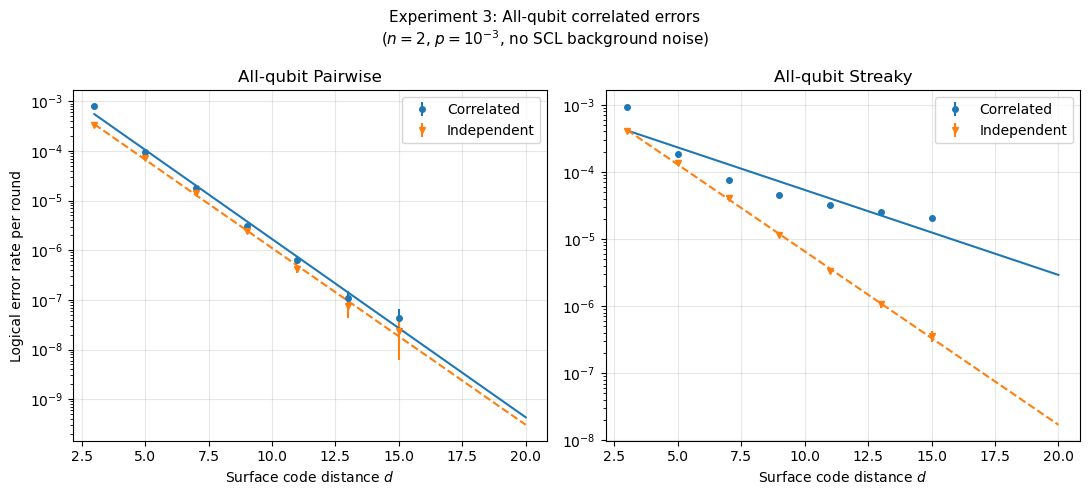

In [33]:
# Plot Experiment 3 from saved data
saved_exp3 = 'data/saved/experiment3'

exp3_corr_pair   = load_correlated(f'{saved_exp3}/pair_all_poly_correlated.csv')
exp3_indep_pair  = load_independent(f'{saved_exp3}/pair_all_poly_independent.csv')
exp3_corr_streak  = load_correlated(f'{saved_exp3}/streak_all_poly_correlated.csv')
exp3_indep_streak = load_independent(f'{saved_exp3}/streak_all_poly_independent.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
e = np.e

c1, c2 = plt.rcParams['axes.prop_cycle'].by_key()['color'][:2]

for ax, corr_data, indep_data, title in zip(
    axes,
    [exp3_corr_pair, exp3_corr_streak],
    [exp3_indep_pair, exp3_indep_streak],
    ['All-qubit Pairwise', 'All-qubit Streaky'],
):
    xc, yc, eyc = format_for_plot(corr_data)
    xi, yi, eyi = format_for_plot(indep_data)

    ax.errorbar(xc, yc, yerr=eyc, label='Correlated', fmt='o', markersize=4, color=c1)
    ax.errorbar(xi, yi, yerr=eyi, label='Independent', fmt='v', markersize=4, color=c2)

    x_fit = np.linspace(3, 20, 100)
    ax.plot(x_fit, e ** np.polyval(np.polyfit(xc, np.log(yc), 1), x_fit), color=c1)
    ax.plot(x_fit, e ** np.polyval(np.polyfit(xi, np.log(yi), 1), x_fit), color=c2, linestyle='--')

    ax.semilogy()
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Surface code distance $d$')
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel('Logical error rate per round')
fig.suptitle('Experiment 3: All-qubit correlated errors\n($n=2$, $p=10^{-3}$, no SCL background noise)', fontsize=11)
fig.tight_layout()
plt.show()

---
## 8. Experiment 4 — Threshold Behaviour (paper §6)

Same models as Experiment 3 but sweeping over multiple **physical error rates** `p` to find the threshold — the critical error rate below which larger codes always perform better.

**Paper parameters:**

| Parameter | Value |
|-----------|-------|
| Models | `LongTimePairAPoly`, `LongTimeStreakAPoly` |
| A | 1, n=2 |
| Distances | [3, 5, 7, 9, 11, 13] |
| **Probabilities** | [1e-4, 2e-4, 5e-4] |
| SCL noise | None |
| max_shots | 10_000_000 |

In [34]:
# ─── PAPER PARAMETERS ─────────────────────────────────────────────────────────
kwargs_exp4 = {
    "num_workers": 12,
    "model_params": {"A": 1, "n": 2},
    "distances": [3, 5, 7, 9, 11, 13],
    "probabilities": [1e-4, 2e-4, 5e-4],
    "scl_noise": [],
    "max_shots": 10_000_000,
    "print_progress": False,
}
# ──────────────────────────────────────────────────────────────────────────────

kwargs_exp4_demo = {
    **kwargs_exp4,
    "distances": [3, 5],
    "probabilities": [1e-4, 5e-4],
    "max_shots": 3_000,
    "num_workers": 2,
}

fp_exp4_pair   = gen_csv_filepaths('./data/output/experiment4/', 'pair_all_poly',   counter=None)
fp_exp4_streak = gen_csv_filepaths('./data/output/experiment4/', 'streak_all_poly', counter=None)

print("Experiment 4 parameters:")
for k, v in kwargs_exp4.items():
    print(f"  {k}: {v}")

Experiment 4 parameters:
  num_workers: 12
  model_params: {'A': 1, 'n': 2}
  distances: [3, 5, 7, 9, 11, 13]
  probabilities: [0.0001, 0.0002, 0.0005]
  scl_noise: []
  max_shots: 10000000
  print_progress: False


In [35]:
# Run Experiment 4 — DEMO
print("Running Experiment 4 — Pairwise all-qubit, correlated...")
sample_correlated_to_file(
    filepath=fp_exp4_pair[0], NoiseModel=LongTimePairAPoly, **kwargs_exp4_demo
)

print("Running Experiment 4 — Pairwise all-qubit, independent...")
sample_independent_to_file(
    filepath=fp_exp4_pair[1], NoiseModel=LongTimePairAPoly, **kwargs_exp4_demo
)

print("Running Experiment 4 — Streak all-qubit, correlated...")
sample_correlated_to_file(
    filepath=fp_exp4_streak[0], NoiseModel=LongTimeStreakAPoly, **kwargs_exp4_demo
)

print("Running Experiment 4 — Streak all-qubit, independent...")
sample_independent_to_file(
    filepath=fp_exp4_streak[1], NoiseModel=LongTimeStreakAPoly, **kwargs_exp4_demo
)

print("Done.")

Running Experiment 4 — Pairwise all-qubit, correlated...
({3: [0.0005], 5: [0.0005]}, {3: [[3000, 3, 6]], 5: [[3000, 2, 10]]})
Running Experiment 4 — Pairwise all-qubit, independent...
Running Experiment 4 — Streak all-qubit, correlated...
({3: [0.0001, 0.0005], 5: [0.0005]}, {3: [[3000, 2, 6], [3000, 7, 6]], 5: [[3000, 1, 10]]})
Running Experiment 4 — Streak all-qubit, independent...
Done.


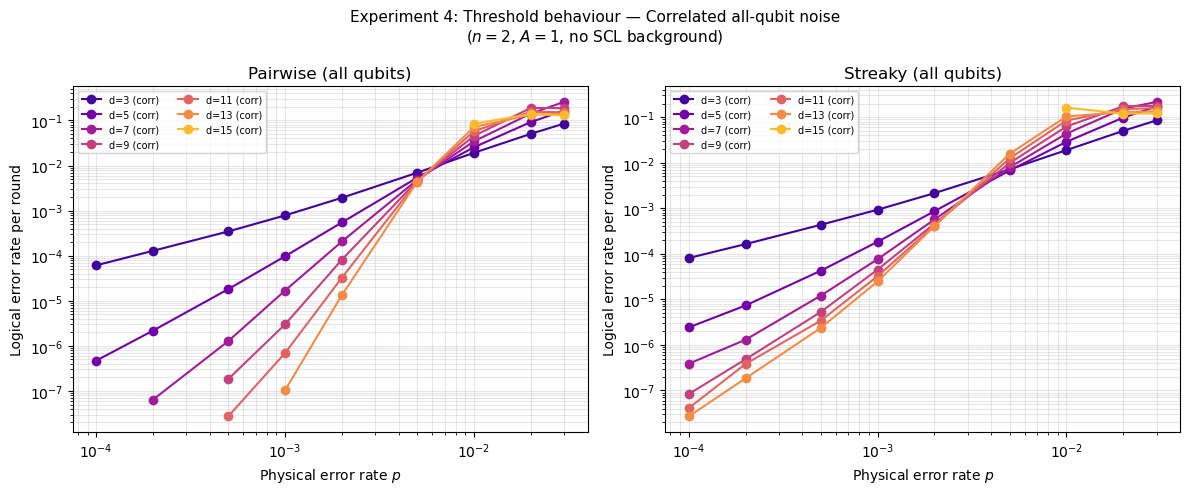

In [36]:
# Plot Experiment 4 threshold plots from saved data
# Threshold plot: physical error rate (x) vs. logical error rate per round (y) for each distance
saved_exp4 = 'data/saved/experiment4'

def load_collected_stats(filepath):
    return sinter.read_stats_from_csv_files(filepath)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, corr_file, indep_file, title in zip(
    axes,
    [f'{saved_exp4}/pair_all_poly_correlated.csv',
     f'{saved_exp4}/streak_all_poly_correlated.csv'],
    [f'{saved_exp4}/pair_all_poly_independent.csv',
     f'{saved_exp4}/streak_all_poly_independent.csv'],
    ['Pairwise (all qubits)', 'Streaky (all qubits)'],
):
    corr_stats  = stats_from_csv(corr_file)
    indep_stats = load_collected_stats(indep_file)

    # Correlated data: physical[d] / logical[d] format
    physical_corr, logical_corr = corr_stats
    colors_d = plt.cm.plasma(np.linspace(0.1, 0.85, len(physical_corr)))

    for (d, ps), color in zip(physical_corr.items(), colors_d):
        ls_vals = logical_corr[d]
        # ls_vals is a list of [shots, errors, rounds]
        p_plot, l_plot = [], []
        for p_val, ls in zip(ps, ls_vals):
            shots, errors, rounds = ls
            per_round, _, _ = calc_per_round_ci(errors, shots, rounds)
            p_plot.append(p_val)
            l_plot.append(per_round)
        ax.plot(p_plot, l_plot, 'o-', color=color, label=f'd={d} (corr)')

    ax.loglog()
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xlabel('Physical error rate $p$')
    ax.set_ylabel('Logical error rate per round')
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)

fig.suptitle('Experiment 4: Threshold behaviour — Correlated all-qubit noise\n($n=2$, $A=1$, no SCL background)', fontsize=11)
fig.tight_layout()
plt.show()

**Reading the threshold plot:** Each line is a different code distance. If lines cross (larger $d$ goes from worse to better as $p$ decreases), a threshold exists. The intersection gives the **error threshold** — below it, QEC helps.

A key finding is that for streaky correlated noise, the threshold may shift, or the crossings may happen at much lower physical error rates.

---
## 9. Running Full-Scale Experiments via Command Line

The demo cells above use reduced parameters. To reproduce the paper exactly, run the experiment scripts from the **project root**:

```bash
# Experiment 1
python -m scripts.experiment1.class0    # Data qubit errors, 10M shots
python -m scripts.experiment1.class1    # Syndrome qubit errors, 10K shots
python -m scripts.experiment1.class2    # Gate errors, 10M shots
python -m scripts.experiment1.figures   # Generate paper figures

# Experiment 2 — decay exponent sweep
python -m scripts.experiment2.class1_poly   # Syndrome, polynomial, n∈{2,3,4,5,∞}
python -m scripts.experiment2.class1_exp    # Syndrome, exponential, n∈{2,3,4,5,∞}
python -m scripts.experiment2.class2_poly   # Gate, polynomial
python -m scripts.experiment2.class2_exp    # Gate, exponential
python -m scripts.experiment2.figures

# Experiment 3 — combined all-qubit
python -m scripts.experiment3.main

# Experiment 4 — threshold sweep
python -m scripts.experiment4.main
```

Results are saved to `data/output/` and can be loaded with `stats_from_csv` (correlated) or `sinter.read_stats_from_csv_files` (independent).

---
## 10. Custom Experiment: Building Your Own Noise Model

You can compose your own experiment by choosing a model class, parameters, and distances.

In [37]:
# Example: compare polynomial vs exponential decay on syndrome qubits
# at distance 3 across a sweep of physical error rates

p_values = [5e-4, 1e-3, 2e-3, 5e-3]
d, r = 3, 6
batch_size = 500
repetitions = 5

results_poly = {}  # {p: (per_round, ci_low, ci_high)}
results_exp  = {}

for p in p_values:
    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_z", rounds=r, distance=d
    )

    # Polynomial decay n=2
    model_poly = LongTimeStreakMPoly(p=p, A=1, n=2)
    shots, errors = model_poly.sample_logical_error_rate(
        circuit, repetitions=repetitions, batch_size=batch_size, return_error_rate=False
    )
    if errors > 0:
        results_poly[p] = calc_per_round_ci(errors, shots, r)

    # Exponential decay n=2
    model_exp = LongTimeStreakMExp(p=p, A=1, n=2)
    shots, errors = model_exp.sample_logical_error_rate(
        circuit, repetitions=repetitions, batch_size=batch_size, return_error_rate=False
    )
    if errors > 0:
        results_exp[p] = calc_per_round_ci(errors, shots, r)

print("Poly decay results:")
for p, (rate, low, high) in results_poly.items():
    print(f"  p={p:.0e}: {rate:.3e} [{rate-low:.3e}, {rate+high:.3e}]")

print("\nExp decay results:")
for p, (rate, low, high) in results_exp.items():
    print(f"  p={p:.0e}: {rate:.3e} [{rate-low:.3e}, {rate+high:.3e}]")

Poly decay results:

Exp decay results:


In [38]:
# Plot the custom comparison
if results_poly and results_exp:
    fig, ax = plt.subplots(figsize=(7, 5))

    ps_poly = sorted(results_poly.keys())
    ys_poly = [results_poly[p][0] for p in ps_poly]
    errs_poly = np.array([[results_poly[p][1], results_poly[p][2]] for p in ps_poly]).T

    ps_exp = sorted(results_exp.keys())
    ys_exp = [results_exp[p][0] for p in ps_exp]
    errs_exp = np.array([[results_exp[p][1], results_exp[p][2]] for p in ps_exp]).T

    ax.errorbar(ps_poly, ys_poly, yerr=errs_poly, label='Poly decay n=2 (streak syndrome)',
                fmt='o-', capsize=3)
    ax.errorbar(ps_exp, ys_exp, yerr=errs_exp, label='Exp decay n=2 (streak syndrome)',
                fmt='s--', capsize=3)

    ax.loglog()
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xlabel('Physical error rate $p$')
    ax.set_ylabel('Logical error rate per round')
    ax.set_title(f'Custom: Polynomial vs. Exponential decay\n(Streaky syndrome, $d={d}$, $r={r}$, demo scale)')
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Insufficient errors recorded at this scale — increase repetitions or batch_size.")

Insufficient errors recorded at this scale — increase repetitions or batch_size.


---
## Summary

| Experiment | Models | Key finding |
|-----------|--------|-------------|
| **1** — Class comparison | `[Pair/Streak][Data/M/C]Poly` | Streaky correlations on syndrome & gate qubits severely degrade performance |
| **2** — Decay exponent sweep | `LongTimeStreak[M/C]Poly`, varying $n$ | Shorter correlation length (larger $n$) → less detrimental; $n=\infty$ recovers independent noise |
| **3** — Combined (all-qubit) | `LongTime[Pair/Streak]APoly` | All-qubit streaky model at $p=10^{-3}$ shows similar qualitative picture |
| **4** — Threshold | `LongTime[Pair/Streak]APoly`, varying $p$ | Threshold still exists but may shift; streaky model shows worse scaling below threshold |

### Key parameters reference

```python
# Noise model constructors
model = LongTimePairPoly(p=2e-3, A=1, n=2, noisy_qubits='data')
model = LongTimeStreakMPoly(p=2e-3, A=1, n=2)           # syndrome qubits
model = LongTimePairCPoly(p=2e-3, A=0.5, n=2)           # two-qubit gates
model = LongTimeStreakAPoly(p=1e-3, A=1, n=2)            # all qubits

# Circuit generation
circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=d*2,
    distance=d,
    after_clifford_depolarization=p,     # optional SCL noise
)

# Sampling to file
sample_correlated_to_file(filepath, NoiseModel, model_params, distances, probabilities, scl_noise, max_shots, ...)
sample_independent_to_file(filepath, NoiseModel, model_params, distances, probabilities, scl_noise, max_shots, ...)

# Loading results
stats = stats_from_csv(filepath)                           # correlated
stats = sinter.read_stats_from_csv_files(filepath)        # independent
```

### Citation

```bibtex
@article{FKam2025,
  doi     = {10.1088/2058-9565/adebab},
  year    = {2025},
  journal = {Quantum Science and Technology},
  volume  = {10},
  pages   = {035060},
  author  = {F Kam, John and Gicev, Spiro and Modi, Kavan and Southwell, Angus and Usman, Muhammad},
  title   = {Detrimental non-Markovian errors for surface code memory},
}
```